# Fundamentos de Teoría Electromagnética

## Teorema de Helmholtz

Elaborado por: **Japhet Arellanos**

Adaptado de las notas del curso de *Fundamentos de Teoría Electromagnética* del Dr. Andrés Tejero Andrade

---

Aquí se dará un breve repaso del **teorema de Helmholtz** debido a su importancia en la comprensión de la Teoría Electromagnética. Lo que este teorema nos dice es que, si conocemos las ecuaciones de un campo vectorial, es decir, su divergencia ($\nabla \cdot \mathbf{F}(\mathbf{r}) = s(\mathbf{r})$) y su rotacional ($\nabla \times \mathbf{F}(\mathbf{r}) = \mathbf{c}(\mathbf{r})$), entonces podemos escribir a la función que representa al campo vectorial como el menos gradiente de una función escalar más el rotacional de una función vectorial:

$$
\mathbf{F}(\mathbf{r}) = - \nabla \varphi(\mathbf{r}) + \nabla \times \mathbf{A}(\mathbf{r})
$$

donde

$$
\varphi(\mathbf{r}) = \frac{1}{4 \pi} \int_{V} \frac{s(\mathbf{r}')}{\mathbf{R}(\mathbf{r}, \mathbf{r}')} \, dV
$$

y

$$
\mathbf{A}(\mathbf{r}) = \frac{1}{4 \pi} \int_{V} \frac{\mathbf{c}(\mathbf{r}')}{\mathbf{R}(\mathbf{r}, \mathbf{r}')} \, dV
$$

bajo las condiciones de que

$$
\nabla \cdot \mathbf{c}(\mathbf{r}) = 0
$$

y

$$
\mathbf{c}(\mathbf{r}) \neq 0 \quad \text{y} \quad s(\mathbf{r}) \neq 0 \qquad \text{en} \, V'
$$

<center><img src = attachment:6976760b-4d60-4feb-b061-30904e94d2d7.png></center>
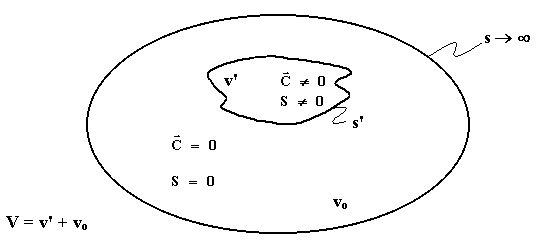

De acuerdo con el teorema de Helmholtz, los campos vectoriales se clasifican de la siguiente manera:

**1. Conservativo**

Aquel cuyas ecuaciones de campo representativas son

$$
\nabla \cdot \mathbf{F} \neq 0 \qquad \nabla \times \mathbf{F} = 0
$$

Su característica es que el campo vectorial se puede expresar como el menos gradiente de una función escalar:

$$
\mathbf{F} = - \nabla \varphi
$$

por lo que su integral de línea es cero:

$$
\oint_{S} \mathbf{F} \cdot d\mathbf{l} = 0
$$

Un ejemplo clásico de un campo conservativo es el campo gravitacional.

<center><img src = attachment:7fb260f6-64b3-4ed8-a0a0-cd20a2c80192.png></center>
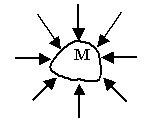

In [2]:
# Importación de módulos y funciones
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Formato de gráficas
plt.style.use('seaborn-paper')
params = {'figure.figsize' : (10, 7),
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'axes.labelsize' : 15,
          'axes.titlesize' : 15,
          'legend.fontsize': 15,
          'lines.linewidth': 1,
          'lines.markersize': 10,
          'grid.color'     : 'darkgray',
          'grid.linewidth' : 0.5,
          'grid.linestyle' : '--',
         }
plt.rcParams.update(params)

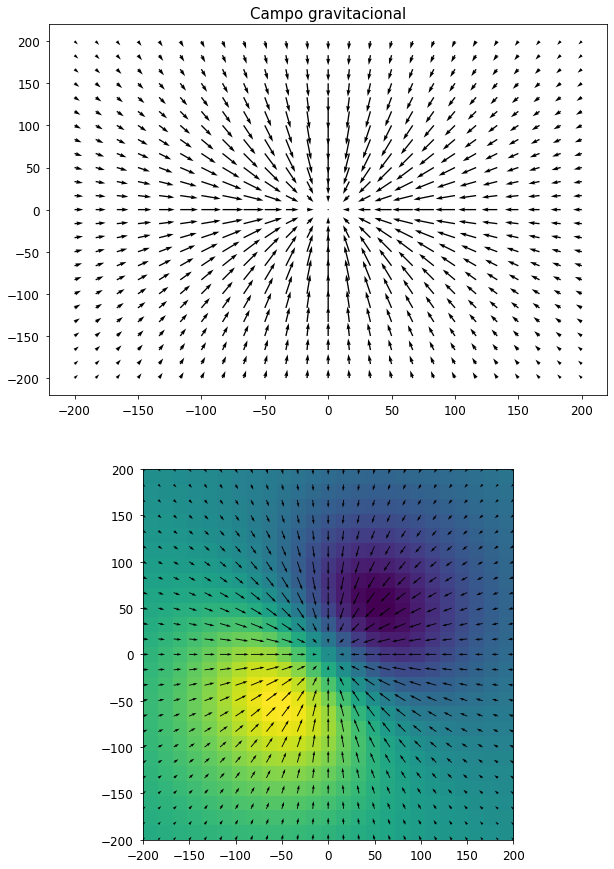

In [31]:
## Campo conservativo (gravitacional)
%matplotlib inline

# Número de muestras en los vectores
N = 25
# Dominio de los vectores direccionales
lim = 200

# Creación de la malla 2D
x, y = np.meshgrid(np.linspace(-lim, lim, N),
                   np.linspace(-lim, lim, N))

# Parémetros del campo gravitacional
G = 6.67e-11
m = 5e14

# Vector de distancia r
r = np.sqrt(x**2 + y**2)

# Componentes cartesianas del campo
g_x = - G * m * x / (r**3 + 1e6)
g_y = - G * m * y / (r**3 + 1e6)

# Generación de la gráfica
fig, axes = plt.subplots(2, 1, figsize = (10, 15))

# Gráfica del campo vectorial
axes[0].set_title('Campo gravitacional')
axes[0].quiver(x, y, g_x, g_y, pivot = 'tail')

axes[1].quiver(x, y, g_x, g_y, pivot = 'tail')
axes[1].imshow(g_x + g_y, origin = 'lower', extent = (x.min(), x.max(), y.min(), y.max()))

plt.show()

**2. Solenoidal**

Aquel que se caracteriza por las siguientes ecuaciones de campo:

$$
\nabla \cdot \mathbf{F} = 0 \qquad \nabla \times \mathbf{F} \neq 0
$$

Cuando se tiene un campo donde estas ecuaciones se cumples en cualquier punto del espacio, se dice que es un campo solenoidal y se caracteriza por que el campo vectorial se puede expresar como el rotacional de $\mathbf{A}$:

$$
\mathbf{F} = \nabla \times \mathbf{A}
$$

y, por tanto, su integral de flujo es cero:

$$
\oint_{S} \mathbf{F} \cdot d\mathbf{s} = 0
$$

El ejemplo típico de un campo solenoidal es el campo magnético, en donde las líneas de fuerza comienzan y terminan en la misma fuente:

<center><img src = attachment:bc26197b-c47f-499c-a1f0-3de6d91e64ab.png></center>
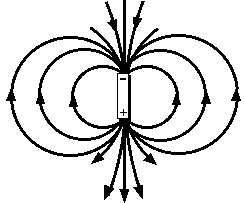

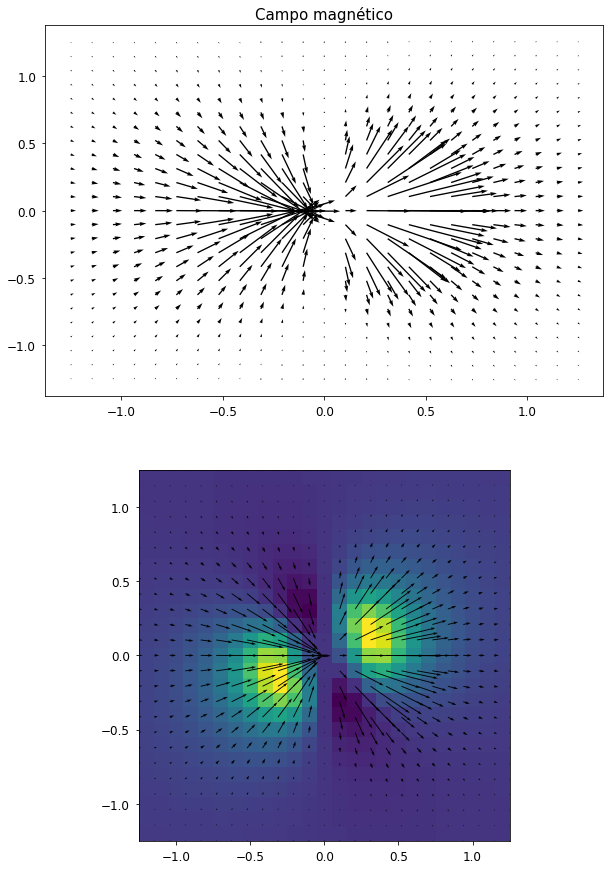

In [32]:
# Visualización de la gráfica en el notebook
%matplotlib inline

# Número de muestras en los vectores
N = 25
# Dominio de los vectores direccionales
lim = 1.25

# Creación de la malla 3D
x, y = np.meshgrid(np.linspace(-lim, lim, N),
                   np.linspace(-lim, lim, N))

# Creación de la magnetización
px, py = np.meshgrid(1000 * np.ones(N),
                     1000 * np.ones(N))

# Parémetros del campo magnético
mu0 = 4 * np.pi * 10e-7

# Vector de distancia r
r = np.sqrt(x**2 + y**2)# + z**2)

# Componentes cartesianas del campo
B_x = (3 * np.dot(px + py, x + y) * x - (r**2 + 1e-2) * px) / (4 * np.pi * (r**5 + 1e-2))
B_y = (3 * np.dot(px + py, x + y) * y - (r**2 + 1e-2) * py) / (4 * np.pi * (r**5 + 1e-2))

# Generación de la gráfica
fig, axes = plt.subplots(2, 1, figsize = (10, 15))

# Gráfica del campo vectorial
axes[0].set_title('Campo magnético')
axes[0].quiver(x, y, B_x, B_y, pivot = 'tail')

axes[1].quiver(x, y, B_x, B_y, pivot = 'tail')
axes[1].imshow(B_x + B_y, origin = 'lower', extent = (x.min(), x.max(), y.min(), y.max()))

plt.show()

**3. Armónico**

Se denomina así al campo que cumple con las siguientes condiciones:

$$
\nabla \cdot \mathbf{F} = 0 \qquad \nabla \times \mathbf{F} = 0
$$

Este campo se puede resolver matemáticamente como un campo solenoidal o un campo conservativo, aunque tradicionalmente se le da un tratamiento conservativo, es decir, cuando $\mathbf{F} = - \nabla \varphi$. En un campo armónico, se enfatiza que en la parte del espacio donde se estudia el fenómeno no hay una fuente presente.

La clasificación anterior se puede resumir en el siguiente diagrama:

<center><img src = attachment:35da641e-eea8-405d-8063-3c85e8540ad7.png></center>

Este diagrama nos dice que un campo complejo se puede separar entre su parte conservativa y su parte solenoidal. A su vez, un campo armónico puede ser tratado como un campo conservativo o un campo solenoidal. De la misma forma, un campo conservativo y/o un campo solenoidal pueden llegar a ser campos armónicos. De esta manera, se explican las interacciones que pueden existir entre los campos.

El corolario del teorema de Helmholtz nos dice que campos físicamentes disímiles que satisfagan igual forma de las ecuaciones de campo, pueden ser tratados matemáticamente de la misma manera sin importar su naturaleza física. Estos no pierden propiedades físicamente, sólo simplifica su tratamiento matemático.

El teorema de Helmholtz es importante en la Teoría Electromagnética dado que esta última se fundamente en este teorema, dado que en todo caso lo que se busca es encontrar la ecuaciones de campo que satisfacen al campo vectorial estudiado para determinar su clasificación y, por ende, su tratamiento.
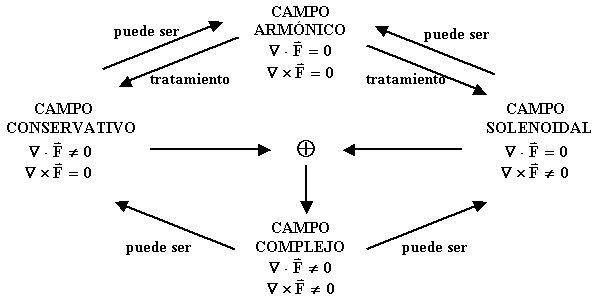